# 1-stage gradient-to-mask pipeline

This notebook trains the selected coordinate-convolution one-stage model at five training-noise levels. Every training condition is stored under `output/one_stage/train_sigma...`. Each trained model is then evaluated at five test-noise levels under that directory. The clean test row is the official protocol result; noisy-test rows are supplementary robustness results.

## Architecture

The model maps gradient features `(batch, 2*(N+1))` directly to mask logits `(batch, grid_size*grid_size)`. The dense front end uses hidden layers `(512, 1024)` with dropout `(0.1, 0.1)`, followed by a 16x16 latent grid and coordinate-convolution decoder channels `(160, 128, 96, 64, 32)`. Training uses BCE+Dice and all-edge weighting. Annulus balancing remains in notebook `04` until its ablation is accepted.

In [1]:
from pathlib import Path
import sys, json
import pandas as pd
import torch

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / 'pyproject.toml').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))

from config import OneModelRunConfig, Stage2ModelConfig, StageTrainingConfig
from datasets import build_two_stage_datasets
from experiments import evaluate_noise_sweep, layer_table, load_one_stage_predictor, parameter_count, save_noise_results, sigma_label
from experiments.notebook import plot_history, plot_noise_curve, plot_shape_curves
from final_models.one_stage import run_one_stage
from models.one_model import GradientToMaskModel

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
OUTPUT = ROOT / 'output' / 'one_stage'
OUTPUT.mkdir(parents=True, exist_ok=True)
TRAIN_SIGMAS = (0.0, 0.001, 0.0025, 0.005, 0.01)
TEST_SIGMAS = TRAIN_SIGMAS
RUN_TRAINING = False  # Missing checkpoints automatically trigger training.

def make_config(train_sigma):
    train_dir = OUTPUT / f'train_sigma{sigma_label(train_sigma)}'
    model = Stage2ModelConfig(hidden_layer_sizes=(512, 1024), dropout_rates=(0.1, 0.1), model_type='coord_conv_decoder', latent_grid_size=16, latent_channels=160, decoder_channels=(160, 128, 96, 64, 32), use_rectangle_edge_weighting=True, use_foreground_pos_weight=False, rectangle_edge_weight=4.0, rectangle_edge_width=3, edge_weight_mode='all', annulus_edge_weight=1.0, annulus_edge_width=3, training=StageTrainingConfig(epochs=170, batch_size=96, learning_rate=0.0005, validation_frequency=60, verbose=False, early_stopping_patience=25, min_epochs=50, min_improvement=0.001, lr_drop_factor=0.5, lr_drop_period=80, weight_decay=0.00025, gradient_clip_norm=0.8, loss_type='bce_dice', dice_loss_weight=1.0, dice_smooth=1.0))
    return OneModelRunConfig(N=10, training_samples=20_000, validation_samples=2_000, test_samples=1_000, noise_sigma=train_sigma, noise_mode='absolute', seed=42, training_noise_replicas=2, training_shape_weights=(('rectangle', 0.25), ('two_circles', 0.45), ('annulus', 0.10), ('ellipse', 0.15), ('circle', 0.05)), use_validation_threshold_sweep=True, model=model, output_dir=train_dir)

model_check = GradientToMaskModel(input_dim=2 * 11, output_dim=32 * 32, hidden_dims=(512, 1024), dropout_rates=(0.1, 0.1), latent_grid_size=16, latent_channels=160, decoder_channels=(160, 128, 96, 64, 32))
architecture = layer_table(model_check, torch.zeros(2, 22))
architecture.to_csv(OUTPUT / 'architecture_layers.csv', index=False)
print('Device:', DEVICE, 'parameters:', parameter_count(model_check))
display(architecture)

Device: cuda parameters: {'total': 43121603, 'trainable': 43121603}


,layer,type,output_shape,parameters,trainable
0,projection.0,Linear,"(2, 512)",11776,11776
1,projection.1,ReLU,"(2, 512)",0,0
2,projection.2,Dropout,"(2, 512)",0,0
3,projection.3,Linear,"(2, 1024)",525312,525312
4,projection.4,ReLU,"(2, 1024)",0,0
5,projection.5,Dropout,"(2, 1024)",0,0
6,projection.6,Linear,"(2, 40960)",41984000,41984000
7,decoder.0,Conv2d,"(2, 160, 16, 16)",230560,230560
8,decoder.1,BatchNorm2d,"(2, 160, 16, 16)",320,320
9,decoder.2,ReLU,"(2, 160, 16, 16)",0,0



=== training sigma=0 ===


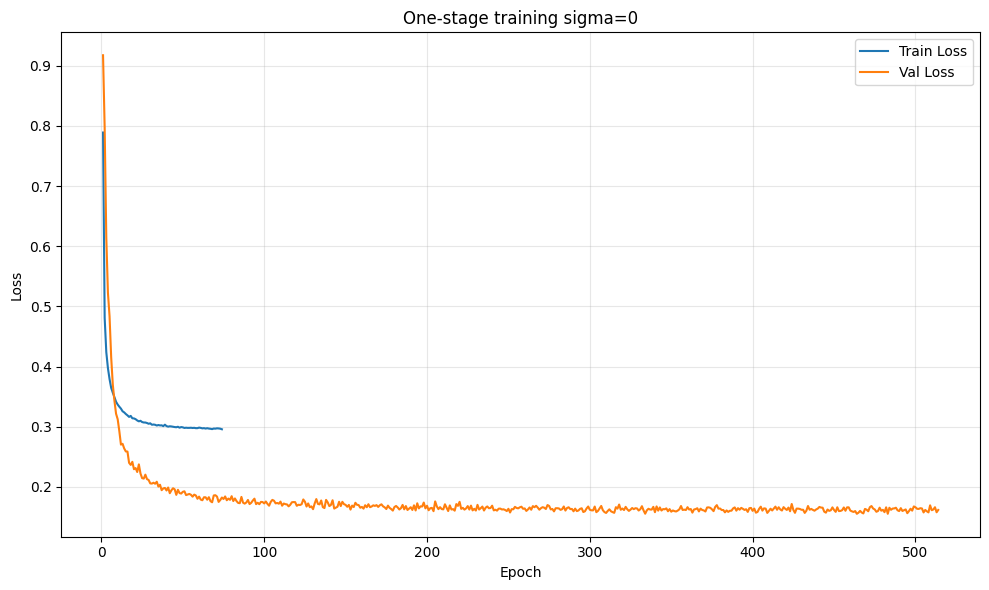

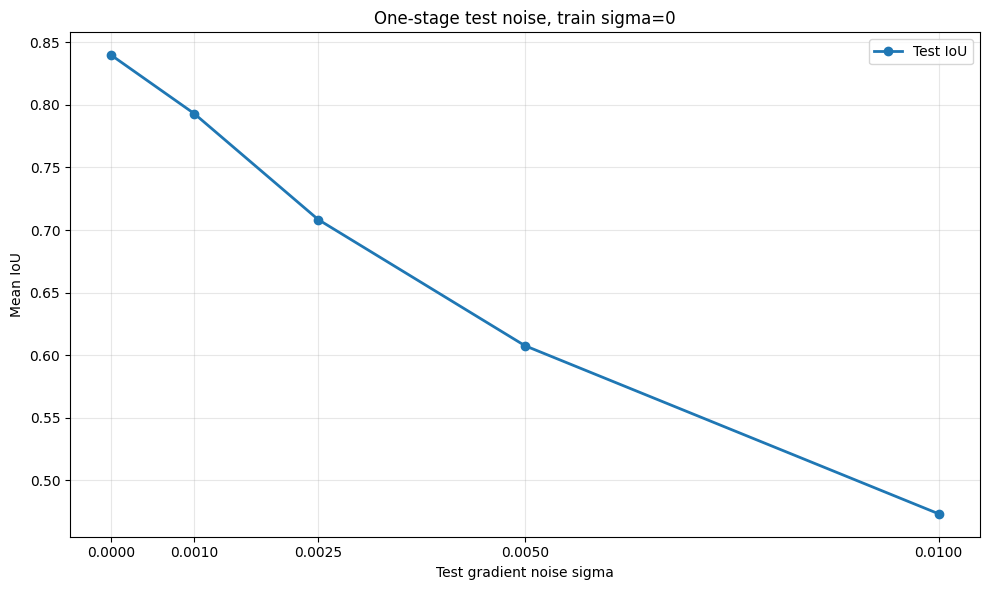

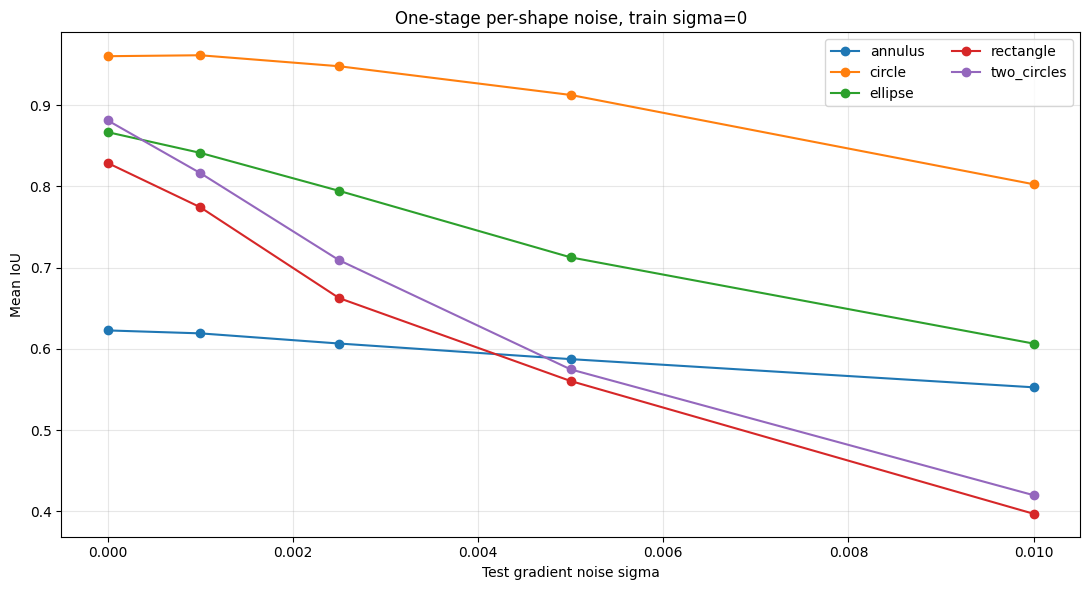


=== training sigma=0.001 ===


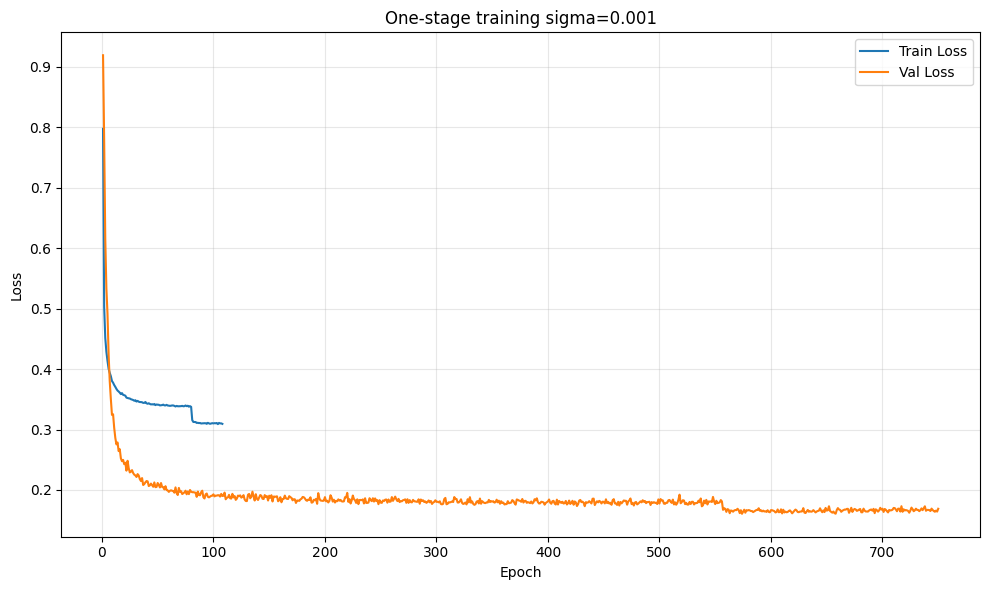

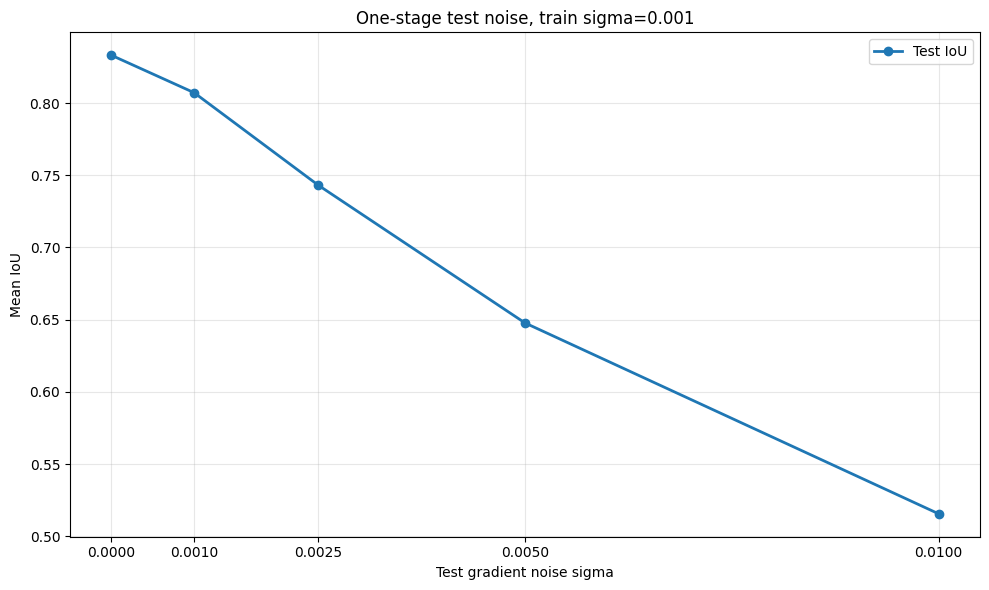

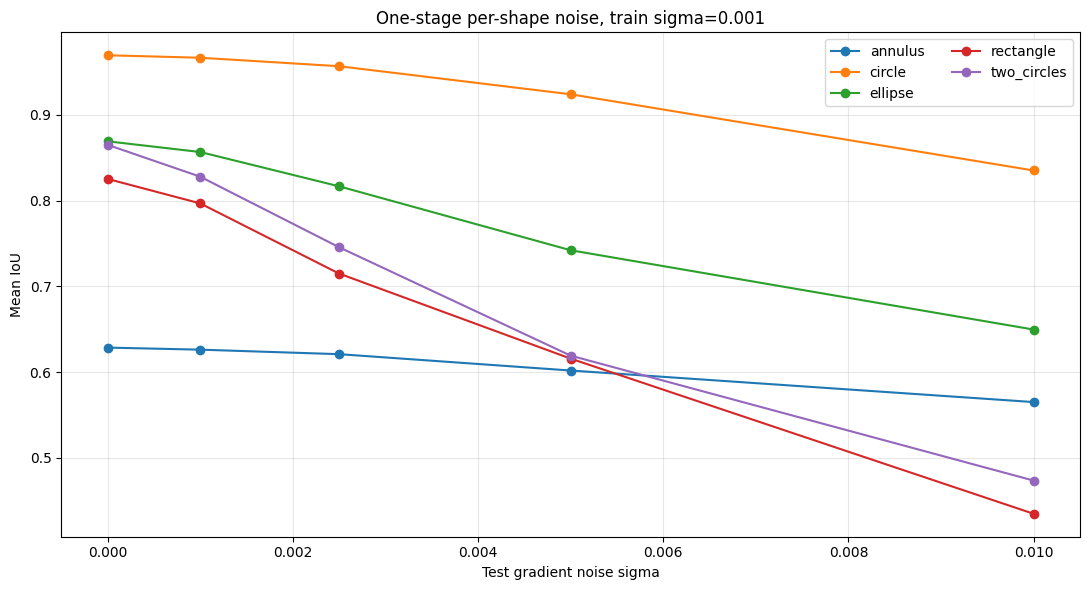


=== training sigma=0.0025 ===


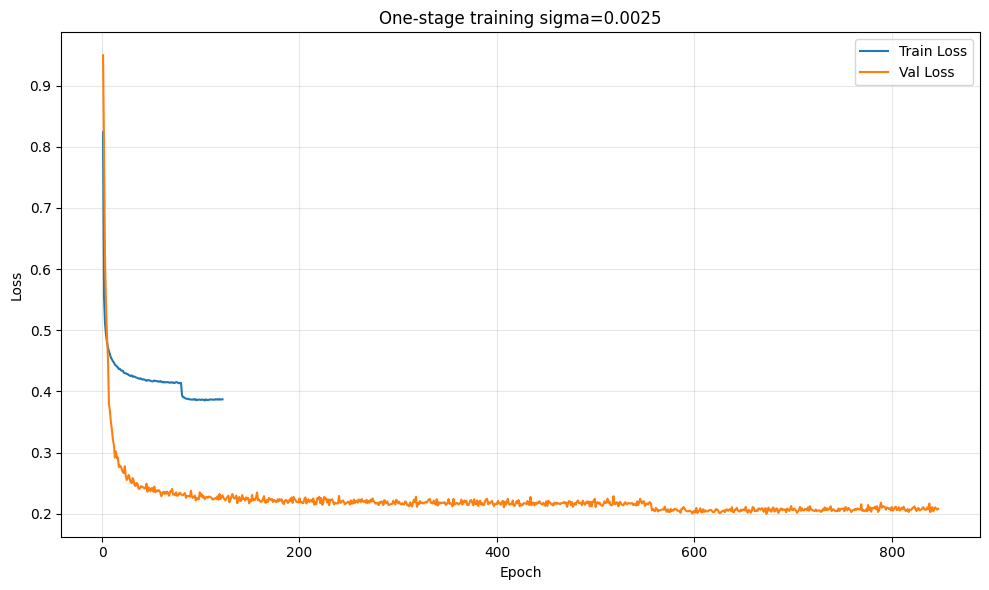

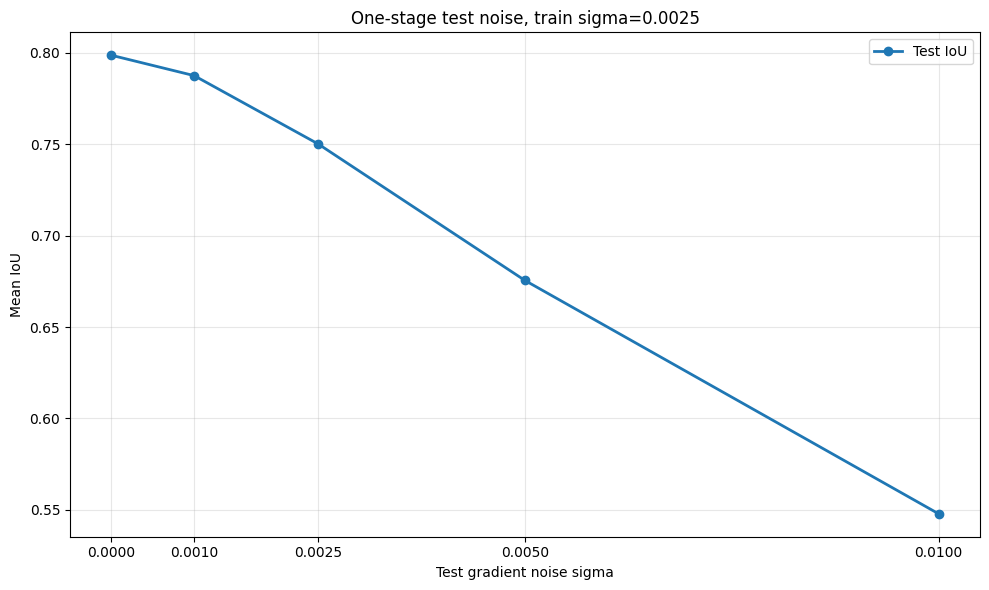

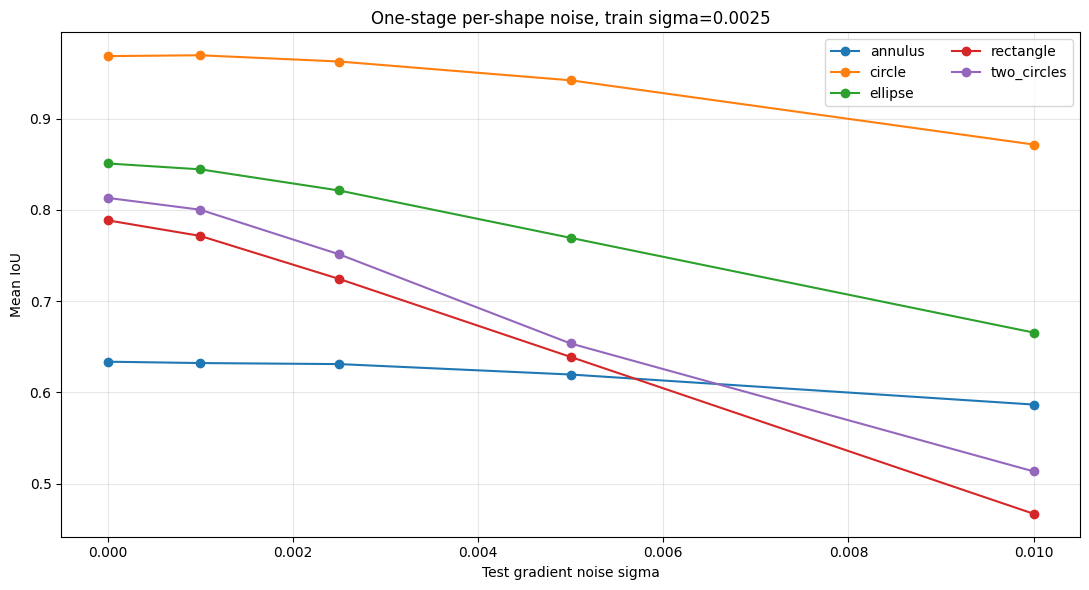


=== training sigma=0.005 ===


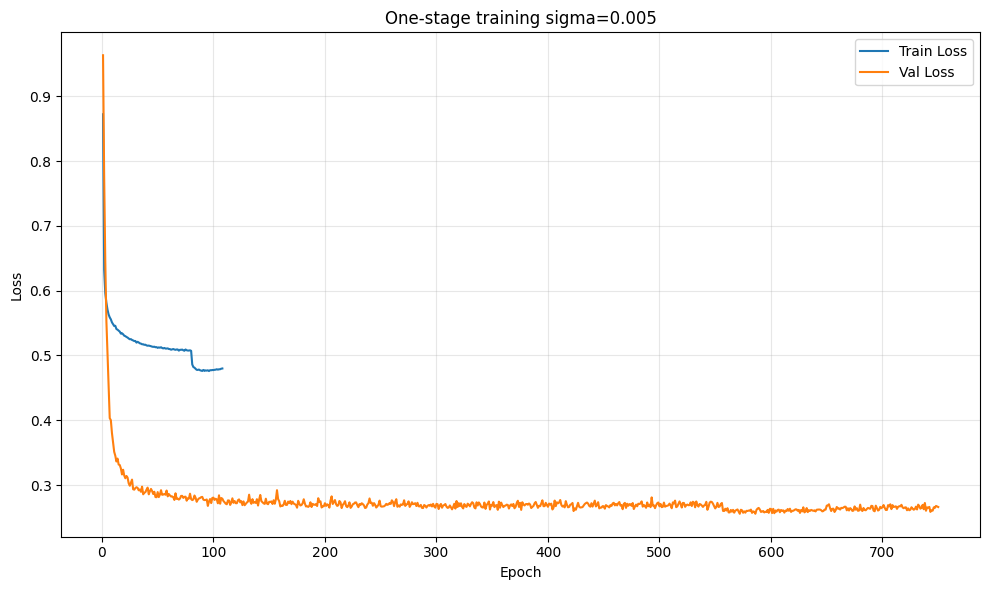

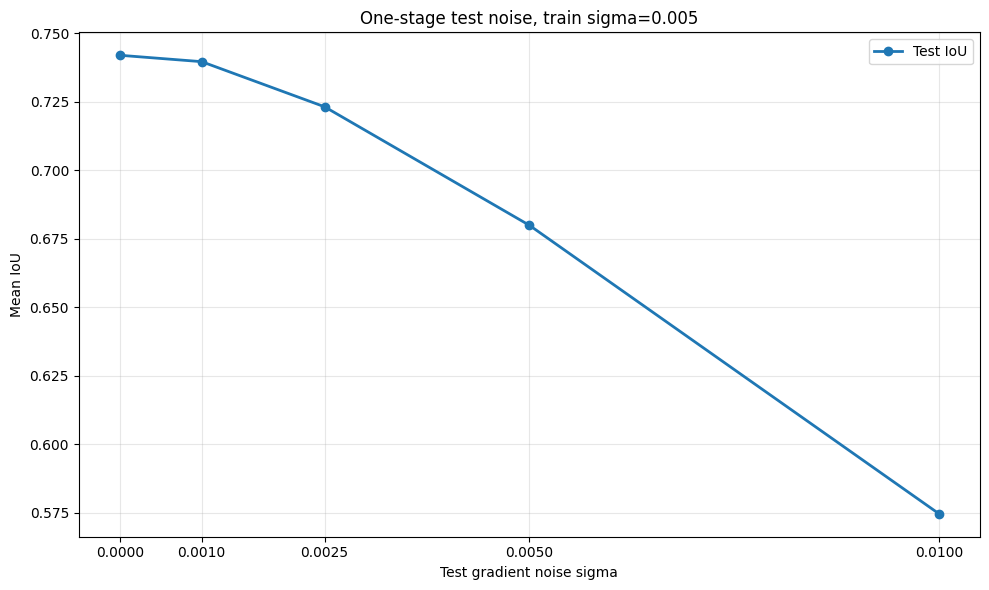

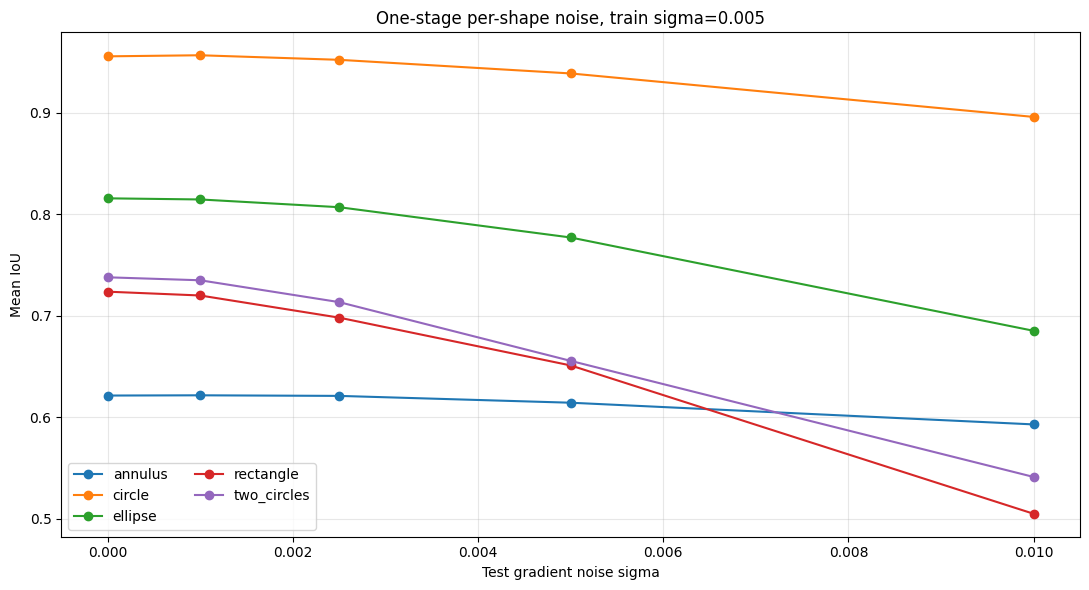


=== training sigma=0.01 ===


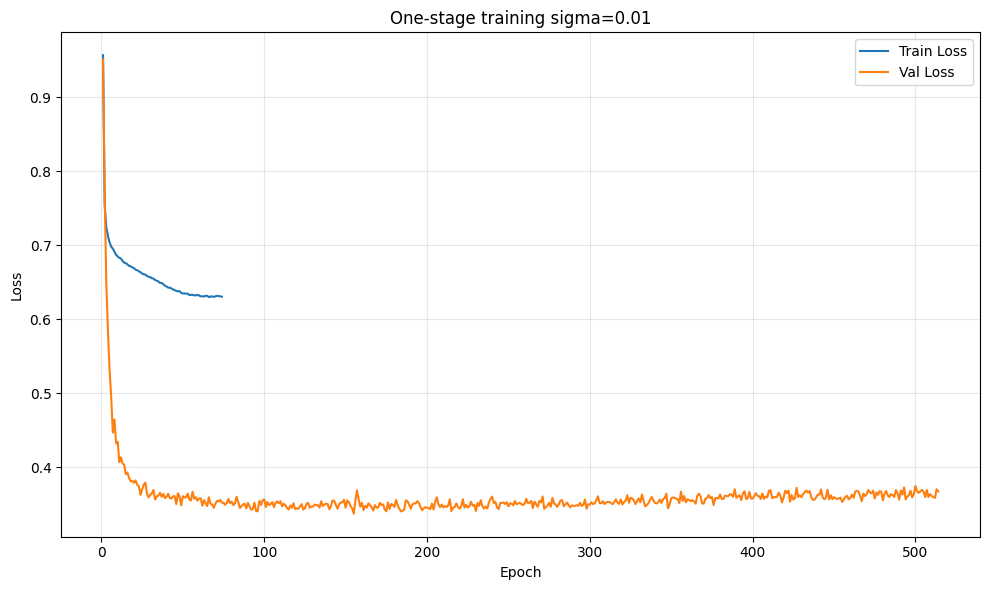

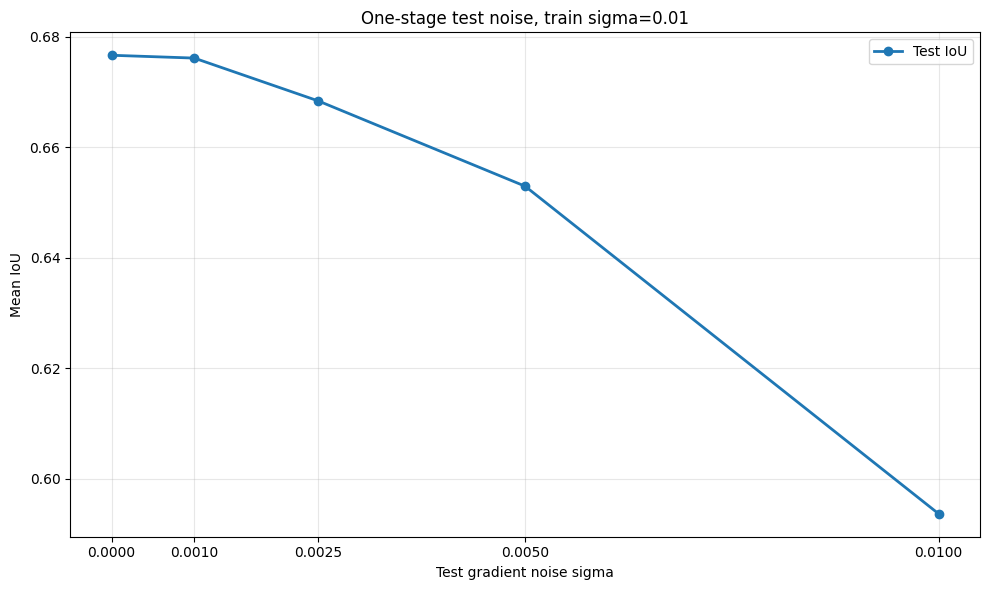

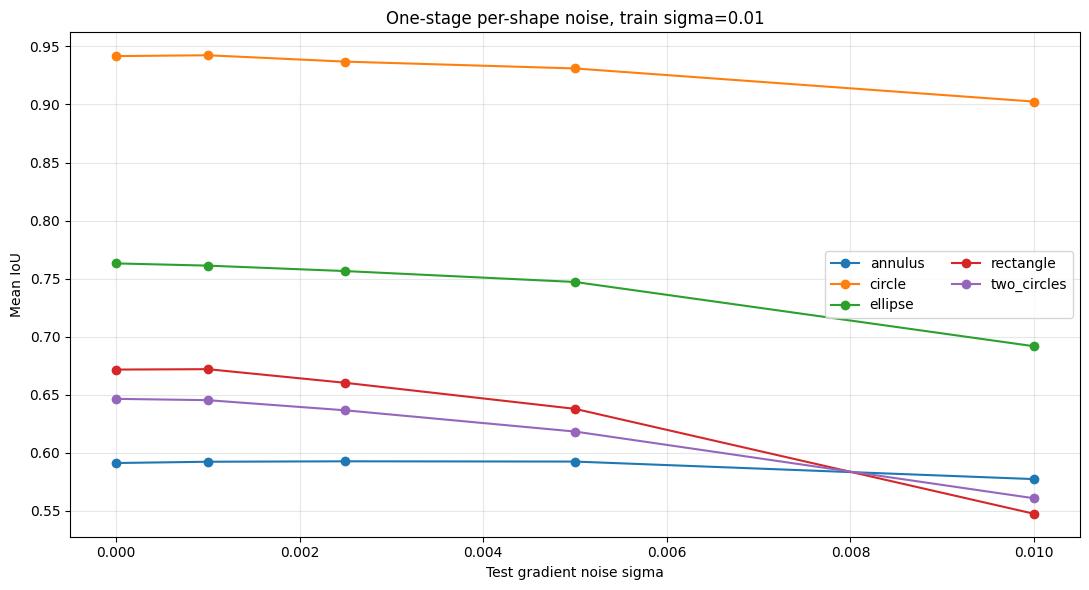

,train_sigma,clean_test_iou,clean_pixel_accuracy,threshold
0,0.0000,0.839722,0.984517,0.45
1,0.0010,0.833051,0.984631,0.55
2,0.0025,0.798736,0.982106,0.50
3,0.0050,0.741887,0.976898,0.45
4,0.0100,0.676620,0.969104,0.45


In [2]:
comparison_rows = []
for train_sigma in TRAIN_SIGMAS:
    config = make_config(train_sigma)
    train_dir = config.output_dir
    summary_path = config.run_output_dir / 'summary.json'
    should_train = RUN_TRAINING or not summary_path.exists()
    print(f'\n=== training sigma={train_sigma:g} ===')
    summary = run_one_stage(config, device=DEVICE) if should_train else json.loads(summary_path.read_text(encoding='utf-8'))
    bundle = build_two_stage_datasets(config)
    predict_logits, summary = load_one_stage_predictor(config.output_dir, config, DEVICE)
    threshold = float(summary['threshold_summary']['selected_threshold'])
    overall, by_shape = evaluate_noise_sweep(predict_logits, bundle.test.gradient_data, bundle.test.masks, bundle.test.shape_types, threshold, noise_levels=TEST_SIGMAS, seed=42)
    save_noise_results(overall, by_shape, train_dir, stem='test_noise_robustness')
    plot_history(summary['training_history'], train_dir / 'training_curves.png', f'One-stage training sigma={train_sigma:g}')
    plot_noise_curve(overall, train_dir / 'test_noise_curve.png', f'One-stage test noise, train sigma={train_sigma:g}')
    plot_shape_curves(by_shape, train_dir / 'test_noise_by_shape.png', f'One-stage per-shape noise, train sigma={train_sigma:g}')
    clean = overall[overall['noise_sigma'] == 0.0].iloc[0]
    comparison_rows.append({'train_sigma': train_sigma, 'clean_test_iou': clean['mean_iou'], 'clean_pixel_accuracy': clean['pixel_accuracy'], 'threshold': threshold})
comparison = pd.DataFrame(comparison_rows)
comparison.to_csv(OUTPUT / 'training_noise_comparison.csv', index=False)
display(comparison)

## Artifact layout

For example, the clean-test and `sigma=0.005` test results for a model trained at `sigma=0.001` are stored at:

`output/one_stage/train_sigma001/test_sigma000/metrics.csv`
`output/one_stage/train_sigma001/test_sigma005/metrics.csv`

Each training directory also contains aggregate CSV/JSON results, weights, datasets, curves, and per-shape metrics.